# Retail Sales Exploratory Data Analysis

**Oasis Infobyte Data Analytics Internship — Level 1, Task 1**

This notebook examines retail transactions to identify sales trends, customer segments, product performance, and practical business opportunities.

**Dataset:** [Retail Sales Dataset by Mohammad Talib on Kaggle](https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset) (CC0). The project copy was downloaded from a public GitHub mirror. The source records are synthetic, so findings demonstrate an EDA workflow rather than real-world market estimates.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = Path('retail_sales_raw.csv')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load and inspect the data

In [2]:
raw_df = pd.read_csv(DATA_PATH)
raw_df.head()

,Transaction ID,Date,Gender,Age,Age Group,Product Category,Quantity,Price per Unit,Total Amount,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Min_age,Max_age,Avg_age,Total Sales Revenue,Average Order value,Category,Sales
0,1,11/24/2023,Male,34,Middle Age,Beauty,3,50,150,NaN,...,NaN,NaN,NaN,18.0,64.0,41.0,456000.0,456.0,Electronics,156905.0
1,2,2/27/2023,Female,26,Adolescent,Clothing,2,500,1000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Clothing,155580.0
2,3,1/13/2023,Male,50,Middle Age,Electronics,1,30,30,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Beauty,143515.0
3,4,5/21/2023,Male,37,Middle Age,Clothing,1,500,500,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,5/6/2023,Male,30,Adolescent,Beauty,2,50,100,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Retain only the transactional fields. The mirrored file includes spreadsheet-style summary columns
# to the right of the source data; these are not part of individual transactions.
required_columns = [
    'Transaction ID', 'Date', 'Gender', 'Age', 'Product Category',
    'Quantity', 'Price per Unit', 'Total Amount'
]
df = raw_df[required_columns].copy()
df.columns = ['transaction_id', 'date', 'gender', 'age', 'product_category',
              'quantity', 'price_per_unit', 'total_amount']
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')
df = df.drop_duplicates().sort_values('date').reset_index(drop=True)
df['month'] = df['date'].dt.to_period('M').astype(str)
df['quarter'] = 'Q' + df['date'].dt.quarter.astype(str)
df['age_group'] = pd.cut(df['age'], bins=[17, 24, 34, 44, 54, 64],
                         labels=['18–24', '25–34', '35–44', '45–54', '55–64'])

print(f'Raw shape: {raw_df.shape}')
print(f'Analysis shape: {df.shape}')
df.head()

Raw shape: (1000, 24)
Analysis shape: (1000, 11)


,transaction_id,date,gender,age,product_category,quantity,price_per_unit,total_amount,month,quarter,age_group
0,522,2023-01-01,Male,46,Beauty,3,500,1500,2023-01,Q1,45–54
1,180,2023-01-01,Male,41,Clothing,3,300,900,2023-01,Q1,35–44
2,559,2023-01-01,Female,40,Clothing,4,300,1200,2023-01,Q1,35–44
3,303,2023-01-02,Male,19,Electronics,3,30,90,2023-01,Q1,18–24
4,979,2023-01-02,Female,19,Beauty,1,25,25,2023-01,Q1,18–24


In [4]:
print('Data types:')
display(df.dtypes.to_frame('dtype'))
print('\nMissing values:')
display(df.isna().sum().to_frame('missing_values'))
print(f'\nDuplicate transaction rows: {df.duplicated().sum()}')

Data types:


,dtype
transaction_id,int64
date,datetime64[us]
gender,str
age,int64
product_category,str
quantity,int64
price_per_unit,int64
total_amount,int64
month,str
quarter,str



Missing values:


,missing_values
transaction_id,0
date,0
gender,0
age,0
product_category,0
quantity,0
price_per_unit,0
total_amount,0
month,0
quarter,0



Duplicate transaction rows: 0


**Observation.** The analysis-ready table has 1,000 transactions and eight original transaction fields. There are no missing values or duplicate rows after retaining the relevant fields; dates have been converted to a true datetime type and month, quarter, and age group are derived for analysis.

## 2. Descriptive statistics

In [5]:
numeric_columns = ['age', 'quantity', 'price_per_unit', 'total_amount']
display(df[numeric_columns].describe().T)

central_tendency = pd.DataFrame({
    'mean': df[numeric_columns].mean(),
    'median': df[numeric_columns].median(),
    'mode': [df[col].mode().iloc[0] for col in numeric_columns],
    'standard_deviation': df[numeric_columns].std()
})
display(central_tendency.round(2))

,count,mean,std,min,25%,50%,75%,max
age,1000.0,41.392,13.681430,18.0,29.0,42.0,53.0,64.0
quantity,1000.0,2.514,1.132734,1.0,1.0,3.0,4.0,4.0
price_per_unit,1000.0,179.890,189.681356,25.0,30.0,50.0,300.0,500.0
total_amount,1000.0,456.000,559.997632,25.0,60.0,135.0,900.0,2000.0


,mean,median,mode,standard_deviation
age,41.39,42.0,43,13.68
quantity,2.51,3.0,4,1.13
price_per_unit,179.89,50.0,50,189.68
total_amount,456.00,135.0,50,560.00


**Observation.** Total transaction value averages roughly $456, while the median is lower, indicating that higher-value purchases pull the average upward. Quantity is concentrated around a small number of units, making bundles and add-on offers a sensible test.

## 3. Monthly and quarterly sales trends

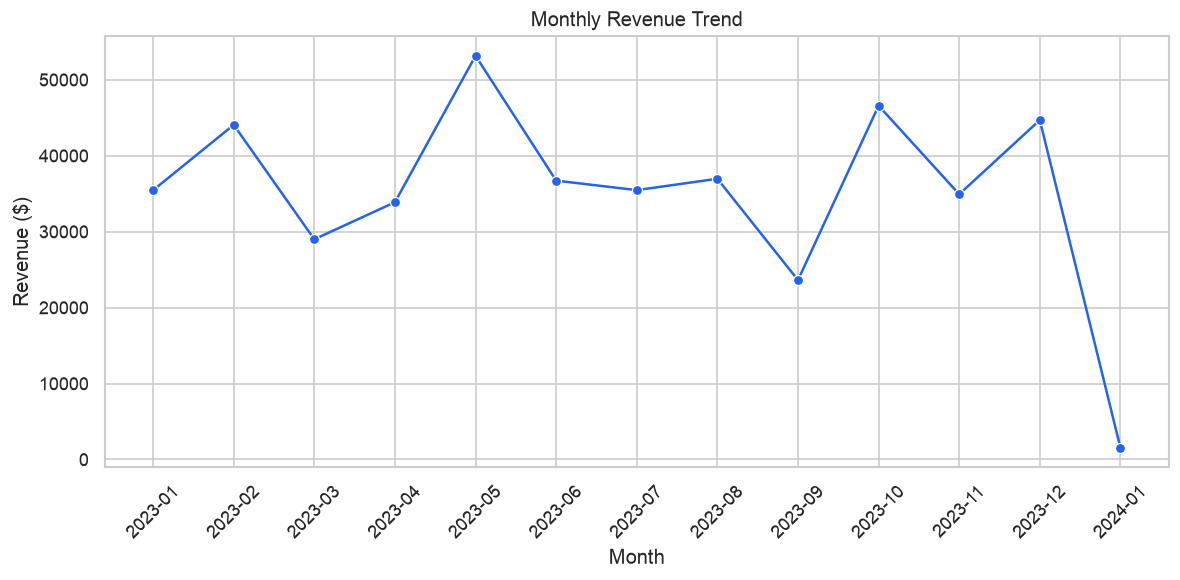

,month,total_amount
4,2023-05,53150
9,2023-10,46580
11,2023-12,44690


In [6]:
monthly_sales = df.groupby('month', as_index=False)['total_amount'].sum()
fig, ax = plt.subplots()
sns.lineplot(data=monthly_sales, x='month', y='total_amount', marker='o', ax=ax, color='#2563eb')
ax.set(title='Monthly Revenue Trend', xlabel='Month', ylabel='Revenue ($)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'monthly_sales_trend.png', bbox_inches='tight')
plt.show()
monthly_sales.sort_values('total_amount', ascending=False).head(3)

**Observation.** Revenue peaks in May. This makes the period leading into May a strong candidate for inventory preparation and campaign testing.

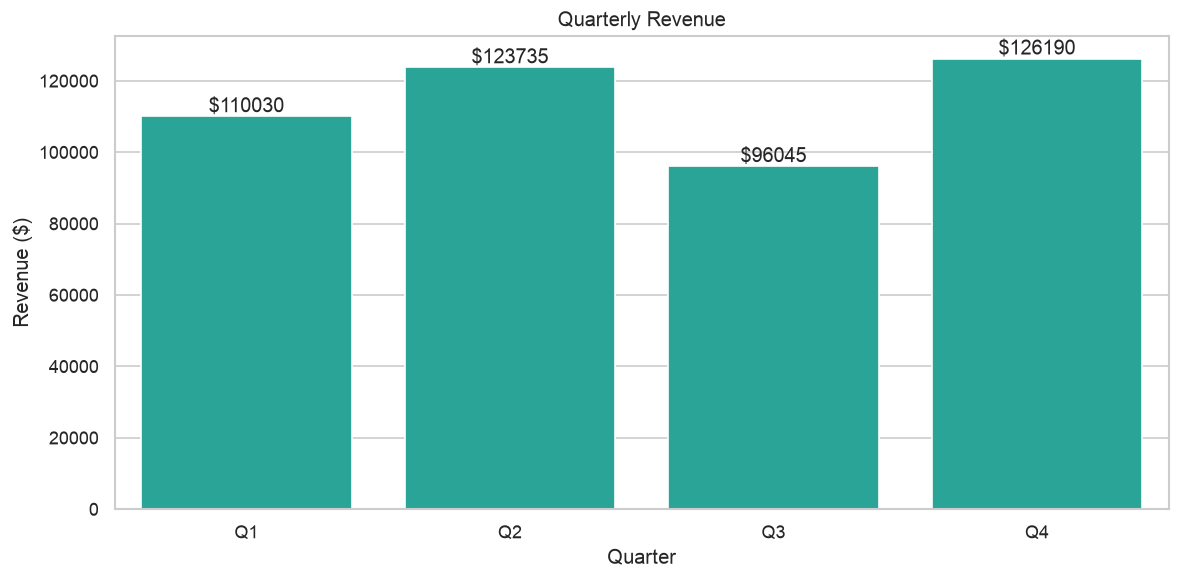

,quarter,total_amount
3,Q4,126190
1,Q2,123735
0,Q1,110030
2,Q3,96045


In [7]:
quarterly_sales = df.groupby('quarter', sort=False, as_index=False)['total_amount'].sum()
fig, ax = plt.subplots()
sns.barplot(data=quarterly_sales, x='quarter', y='total_amount', ax=ax, color='#14b8a6')
ax.set(title='Quarterly Revenue', xlabel='Quarter', ylabel='Revenue ($)')
for container in ax.containers:
    ax.bar_label(container, fmt='$%0.0f')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quarterly_sales_trend.png', bbox_inches='tight')
plt.show()
quarterly_sales.sort_values('total_amount', ascending=False)

**Observation.** Q4 generates the highest total revenue, while May is the strongest individual month. Planning should protect both the May opportunity and the broader Q4 peak.

## 4. Customer demographics

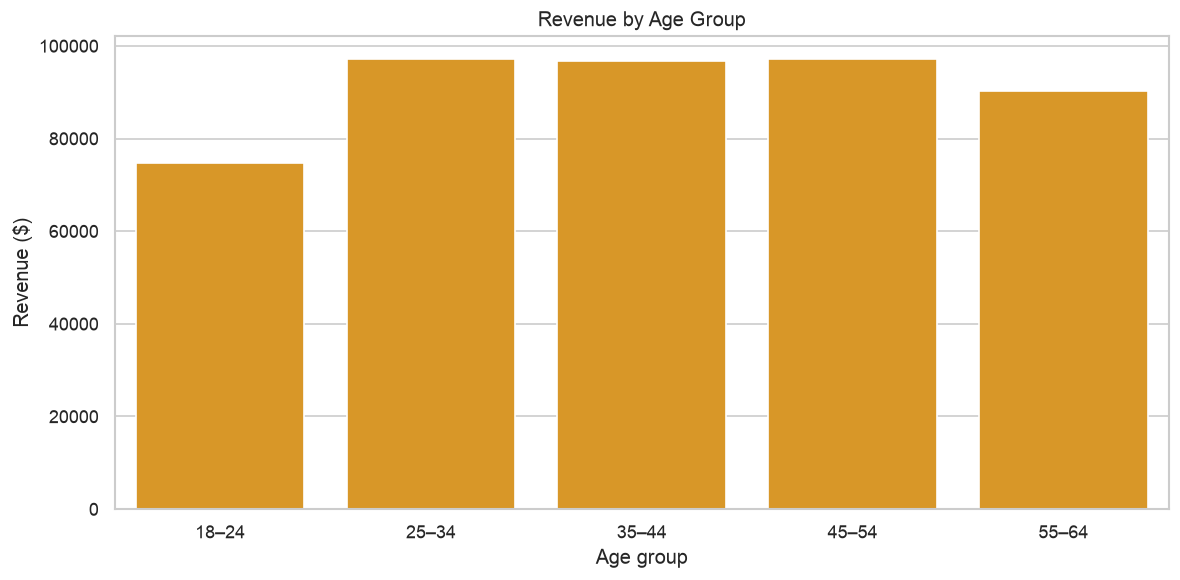

,age_group,total_amount
3,45–54,97235
1,25–34,97090
2,35–44,96835
4,55–64,90190
0,18–24,74650


In [8]:
age_sales = df.groupby('age_group', observed=False, as_index=False)['total_amount'].sum()
fig, ax = plt.subplots()
sns.barplot(data=age_sales, x='age_group', y='total_amount', ax=ax, color='#f59e0b')
ax.set(title='Revenue by Age Group', xlabel='Age group', ylabel='Revenue ($)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'revenue_by_age_group.png', bbox_inches='tight')
plt.show()
age_sales.sort_values('total_amount', ascending=False)

**Observation.** Customers aged 45–54 are the highest-revenue age group, with customers aged 25–44 close behind. This broad working-age audience is a strong priority for campaigns, while younger customers warrant tailored experiments.

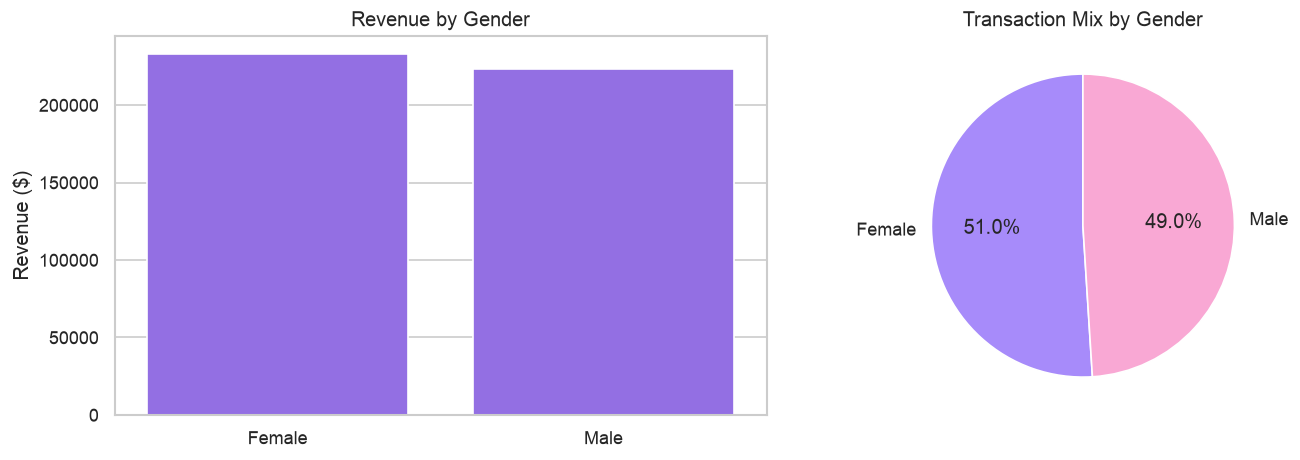

,gender,revenue,transactions
0,Female,232840,510
1,Male,223160,490


In [9]:
gender_sales = df.groupby('gender', as_index=False).agg(revenue=('total_amount', 'sum'), transactions=('transaction_id', 'count'))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=gender_sales, x='gender', y='revenue', ax=axes[0], color='#8b5cf6')
axes[0].set(title='Revenue by Gender', xlabel='', ylabel='Revenue ($)')
axes[1].pie(gender_sales['transactions'], labels=gender_sales['gender'], autopct='%1.1f%%', startangle=90, colors=['#a78bfa', '#f9a8d4'])
axes[1].set_title('Transaction Mix by Gender')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gender_analysis.png', bbox_inches='tight')
plt.show()
gender_sales

**Observation.** Female customers contribute slightly more revenue and transactions. The difference is modest, so gender should support segmentation—not replace product and age-based targeting.

## 5. Product and category performance

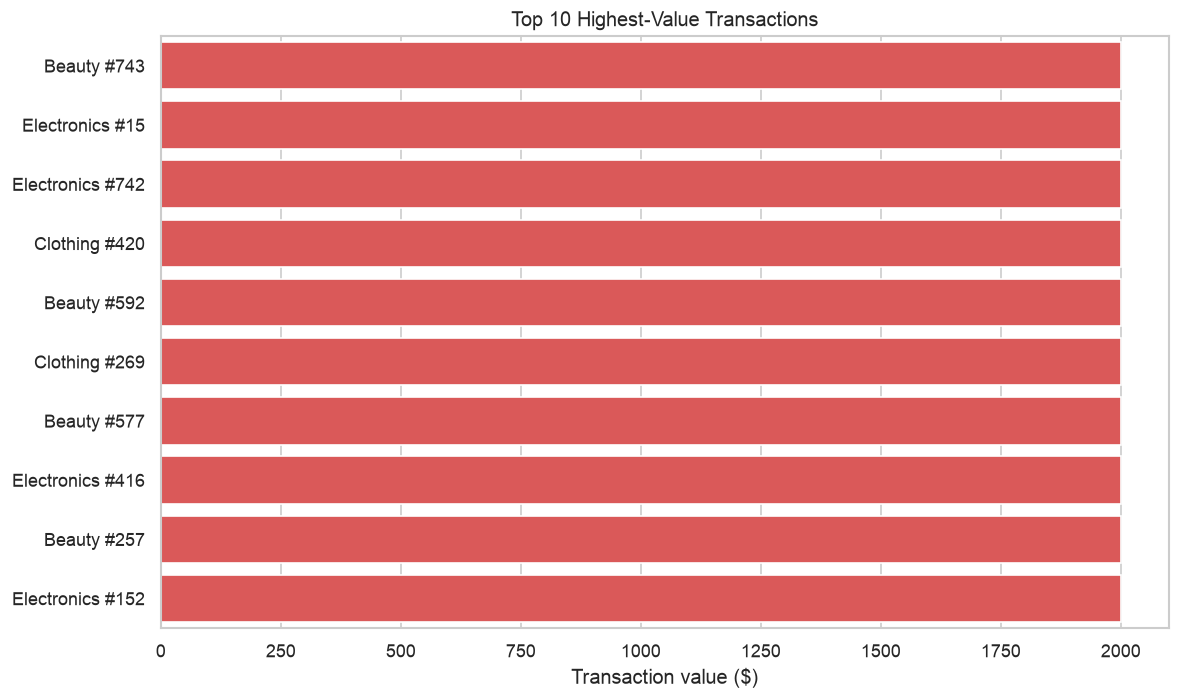

,transaction_id,product_category,quantity,total_amount
37,743,Beauty,4,2000
38,15,Electronics,4,2000
47,742,Electronics,4,2000
52,420,Clothing,4,2000
55,592,Beauty,4,2000
78,269,Clothing,4,2000
117,577,Beauty,4,2000
126,416,Electronics,4,2000
131,257,Beauty,4,2000
157,152,Electronics,4,2000


In [10]:
# This dataset identifies categories rather than individual product names, so the top-10 chart
# reports the highest-revenue transaction IDs as the most granular available product proxies.
top_10_transactions = df.nlargest(10, 'total_amount')[['transaction_id', 'product_category', 'quantity', 'total_amount']].copy()
top_10_transactions['label'] = top_10_transactions['product_category'] + ' #' + top_10_transactions['transaction_id'].astype(str)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_10_transactions, y='label', x='total_amount', ax=ax, color='#ef4444')
ax.set(title='Top 10 Highest-Value Transactions', xlabel='Transaction value ($)', ylabel='')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_10_transactions.png', bbox_inches='tight')
plt.show()
top_10_transactions[['transaction_id', 'product_category', 'quantity', 'total_amount']]

**Observation.** The source does not include product names or SKU-level IDs. To remain transparent, the “top 10 products” requirement is addressed with the ten highest-value transaction-level product purchases, labelled by their available category and transaction ID.

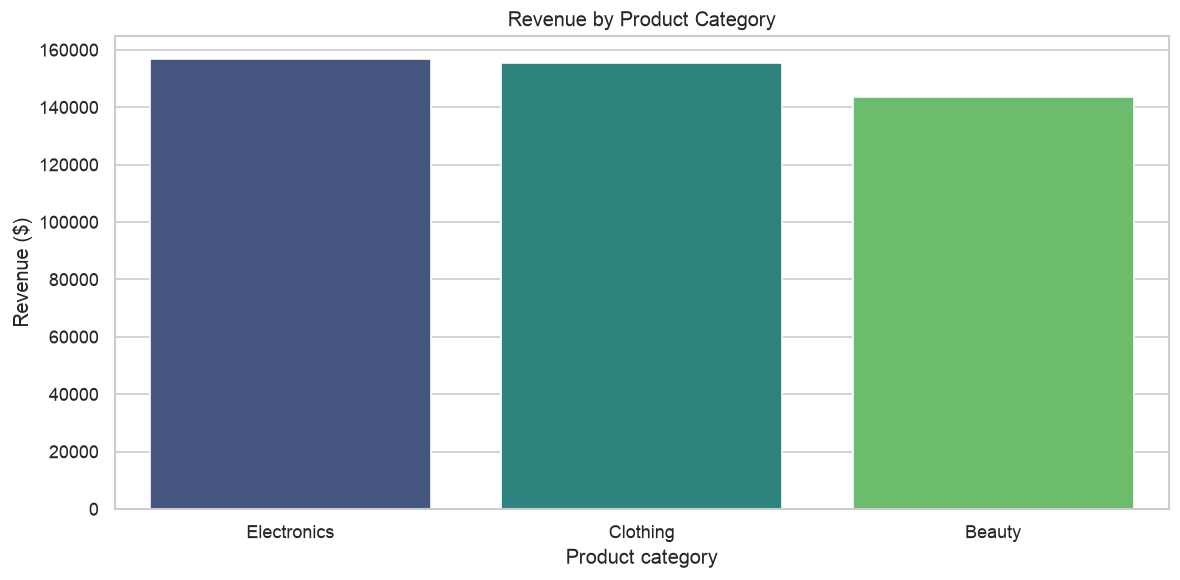

,product_category,revenue,avg_transaction_value,transactions
2,Electronics,156905,458.79,342
1,Clothing,155580,443.25,351
0,Beauty,143515,467.48,307


In [11]:
category_sales = df.groupby('product_category', as_index=False).agg(
    revenue=('total_amount', 'sum'),
    avg_transaction_value=('total_amount', 'mean'),
    transactions=('transaction_id', 'count')
)
fig, ax = plt.subplots()
sns.barplot(data=category_sales.sort_values('revenue', ascending=False), x='product_category', y='revenue', ax=ax, palette='viridis')
ax.set(title='Revenue by Product Category', xlabel='Product category', ylabel='Revenue ($)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'revenue_by_category.png', bbox_inches='tight')
plt.show()
category_sales.sort_values('revenue', ascending=False).round(2)

**Observation.** Electronics is the largest revenue category. It deserves prominent placement in peak-period promotions, with complementary Clothing and Beauty items tested as cross-sell options.

## 6. Relationships between numerical variables

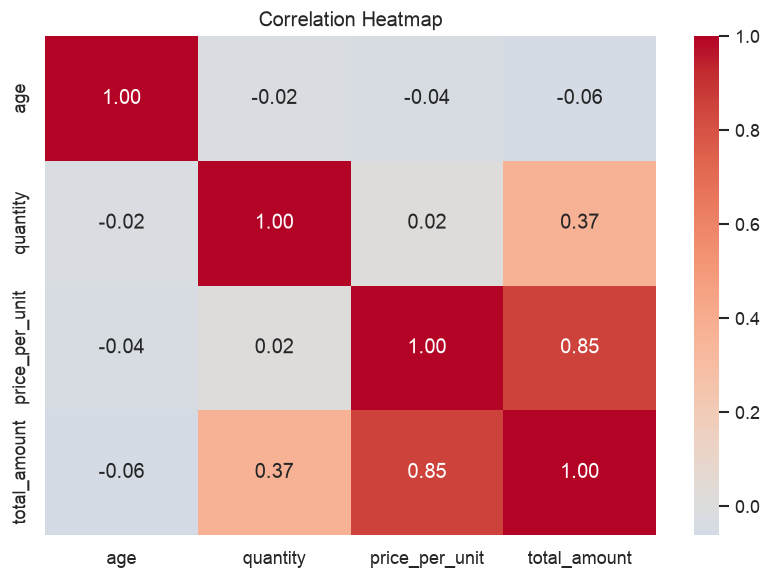

In [12]:
corr = df[numeric_columns].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Observation.** Total amount has the strongest relationship with quantity and unit price, as expected from the revenue calculation. Age has little linear relationship with spend, so age is more useful for grouped segmentation than for predicting order value alone.

## 7. Additional insight: category preference by age group

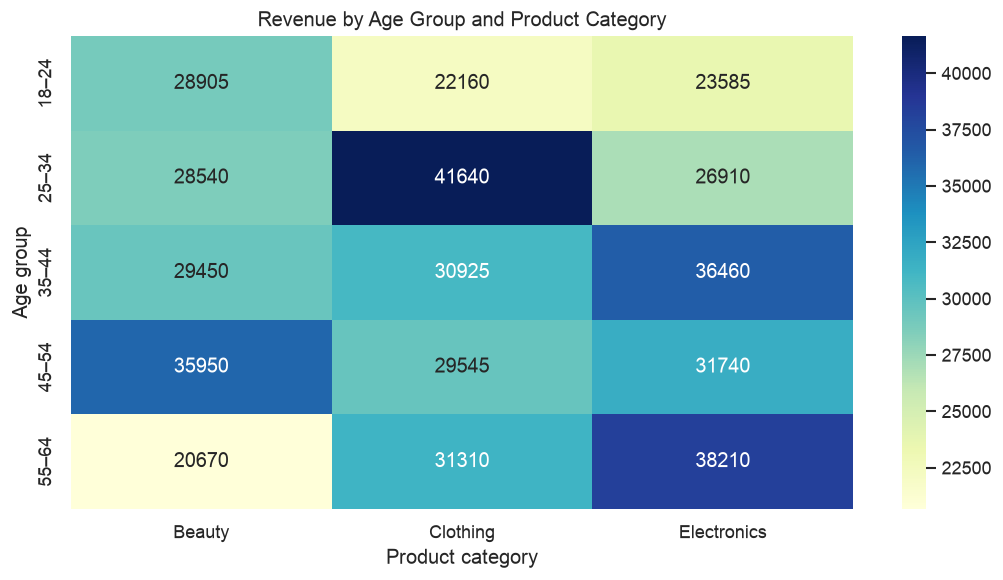

product_category,Beauty,Clothing,Electronics
age_group,,,
18–24,28905,22160,23585
25–34,28540,41640,26910
35–44,29450,30925,36460
45–54,35950,29545,31740
55–64,20670,31310,38210


In [13]:
age_category = pd.pivot_table(df, index='age_group', columns='product_category', values='total_amount', aggfunc='sum', observed=False).fillna(0)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(age_category, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax)
ax.set(title='Revenue by Age Group and Product Category', xlabel='Product category', ylabel='Age group')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'age_category_heatmap.png', bbox_inches='tight')
plt.show()
age_category

**Observation.** Revenue is distributed across the 25–54 range, with category-level peaks varying by age group. This supports targeted category creative rather than a single demographic message.

## Recommendations and conclusion

### Actionable recommendations

1. **Plan for two seasonal opportunities.** Set campaign and inventory targets before May, the highest-revenue month, and before Q4, the highest-revenue quarter.
2. **Lead with Electronics.** Use Electronics as the anchor category in promotions and test cross-sell bundles with Clothing or Beauty to raise basket value.
3. **Focus on customers aged 25–54.** Create age-appropriate campaigns for this consistently high-revenue group, led by ages 45–54; then run smaller, measurable offers for 18–24 customers to grow the lowest-revenue segment.
4. **Use price and quantity together.** Since both drive transaction value, test multi-unit discounts or threshold-based add-ons instead of broad price reductions.

### Conclusion

The 1,000-record retail dataset shows two seasonal opportunities—May as the highest-revenue month and Q4 as the strongest quarter—alongside strong revenue from Electronics and customers aged 25–54. The analysis recommends concentrating inventory and campaign effort on these high-value areas while using targeted bundles and segment experiments to expand revenue elsewhere.

## Reproducibility

Run the cells from top to bottom. Chart files are saved in `outputs/`; selected files are copied to `screenshots/` for the submission package after execution.